# **GEOMETRY OF TACTICAL EVENTS: FROM DICTIONARY TO CONTEXT**

This notebook investigates how `TacticalBert` organizes the vocabulary of football. It is divided in two parts:
- **Static events geometry**: how the model relates different event in its base embedding layer.

- **Contextual manifolds**: how specific events (Passes) shift their meaning and representation based on spatial coordinates and game situations.

## **DICTIONARY of FOOTBALL**
Static embeddings are the weights stored in the model's initial lookup table. By analyzing these vectors, it's possible to see if the model has learned an inherent "taxonomy" of football and understand why it groups actions together.

This notebook utilizes the StatsBomb event taxonomy as the fundamental vocabulary for the model. Below are the brief descriptions of the events analyzed:

- **Offensive**: `Shot` an attempt to score a goal, `Goal` a successful shot that crosses the goal line. 

- **Constructive & Build-up**: `Pass` a transfer of the ball from one teammate to another, `Carry` a player moving with the ball under control, `Dribble` an attempt by a player to beat an opponent while in possession of the ball, `Ball Receipt`: the successful collection of a pass from a teammate.

- **Defensive**: `Interception` preventing an opponent's pass intercepting its path, `Block` a player physically obstructing a shot or a pass, `Clearance` when a player kicks the ball away from the goal with no intended recipient, `Ball Recovery` gaining possession of a loose ball (neither team has control), `Duel` a 50/50 challenge for the ball between two players, `Pressure` an action where a player applies defensive pressure on an opponent in possession, `Goal Keeper` for specific interventions of this role, `Shield` using body to physically block an opponent from reaching the ball.

- **Negative & Infractions**: `Miscontrol` accidental loss of possession of the ball, `Dispossessed` a player losing the ball to an opponent through a tackle, `Error` a mistake made by a player that leads to a shot or a dangerous situation,`Bad Behaviour` a disciplinary event (yellow card, red card), `Dribble Past` defensive failure trying to stop an opponent's dribble, `Foul Committed` and `Foul Won` respectively any infraction of the rules and successfully drawing a foul from an opponent, `Own Goal Against` and `Own Goal For` respectively a player accidentaly scores into own net or an opponent (one conseguence of the other).

## **STATIC EVENTS GEOMETRY**

### **SETUP and DATA LOADING**

In [1]:
import torch
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
import json
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

cwd = Path.cwd()
proj_root = cwd
while proj_root != proj_root.parent and not (proj_root / "src").is_dir():
    proj_root = proj_root.parent
sys.path.insert(0, str(proj_root))

from src.config import Config
from src.model import TacticalBert

### **LOADING VOCAB and MODEL**

In [2]:
vocab_path = Config.PROCESSED_DATA_DIR / "vocab.json"
with open(vocab_path, 'r') as f:
    full_vocab = json.load(f)

type_vocab = full_vocab['type_name']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TacticalBert(vocab_size=len(type_vocab)).to(device)
checkpoint_path = Config.BEST_MODEL_PATH

if checkpoint_path.exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Model loaded successfully.")
else:
    print("Warning: Checkpoint not found. Using random weights.")

Model loaded successfully.


### **EXTRACTING STATIC WORD EMBEDDINGS and ASSIGNING CATEGORY**

This code accesses the raw weight matrix from the model's word embeddings layer, representing the static identity of each tactical event. These vectors are mapped to categories: Offensive, Build-up, Defensive and Errors/Fouls.

In [3]:
# These are the raw weights of the embedding layer
static_embeddings = model.bert.bert.embeddings.word_embeddings.weight.data.cpu().numpy()

categories_map = {
    "Special": ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"],
    "Offensive": ["Shot", "Goal"],
    "Build-up": ["Pass", "Carry", "Dribble"],
    "Defensive": ["Block", "Clearance", "Interception", "Ball Recovery", "Duel", "Pressure", "Shield", "Goal Keeper"],
    "Errors/Fouls": ["Bad Behaviour", "Foul Committed", "Foul Won", "Own Goal For", "Own Goal Against", "Error", "Miscontrol", "Dispossessed", "Offside", "Dribbled Past"]
}

vectors, labels, categories = [], [], []

for name, idx in type_vocab.items():
    vectors.append(static_embeddings[idx])
    labels.append(name)
    
    # Assign category
    found_cat = "Other"
    for cat_name, event_list in categories_map.items():
        if name in event_list:
            found_cat = cat_name
            break
    categories.append(found_cat)


### **DIMENSIONALITY REDUCTION (PCA) and VISUALIZATION**
To transform the high-dimensional latent space into a navigable visualization, the code utilizes **Principal Component Analysis (PCA)**. PCA is chosen because it provides more stability than UMAP when dealing with a small vocabulary size like in the case of football. After reducing the vectors to two dimensions, the data is cleaned to exclude technical tokens and visualized through an interactive scatter plot. 

In [4]:
# For a small number of points (vocab size ~30), PCA is often more stable than UMAP
pca = PCA(n_components=2)
coords = pca.fit_transform(np.array(vectors))

df_static = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'Event': labels,
    'Category': categories
}).query("Category != 'Special'") # Filter out technical tokens

#Interactive Visualization
fig = px.scatter(
    df_static, x='x', y='y', text='Event', color='Category',
    title="<b>Semantic dictionary of football events</b><br>",
    template="plotly_dark", width=900, height=600
)

fig.update_traces(textposition='top center', marker=dict(size=14, opacity=0.8, line=dict(width=1, color='white')))
fig.show()


Some interesting observation regarding the model's internal worldview:

- The `Pass` is positioned relatively close to the origin. This reflects its nature as a connective token, as a pass can be defensive, offensive, or neutral depending on the context.

- Events such as `Ball Recovery` and `Interception` are mapped with high horizontal proximity. This indicates a central subspace that represents change of possession.

- `Bad Behaviour` and `Goal` share nearly identical coordinates. This could indicate a strong contextual correlation in the training data, likely capturing events that frequently occur in the immediate aftermath of a scored goal.

- There is a tight cluster formed by `Miscontrol`, `Foul Committed` and `Shot`. All these events are similar to `Goal`. This suggests the model has learned that an attacking sequence typically terminates in one of these ways. 

- `Dribbled Past` is close to `Interception`. This proximity reveals that the model views these two events as one mirroring the other: both occur in the same situation where a defender attempts to interrupt the ball's flow. 

- `Own Goal Against` is closer to `Pass` than a `Shot`, this distinction could be interpreted as a lack of intent that characterizes a deliberate shot; treating it more like a misplaced pass that ended in the net.


## **CONTEXTUAL MANIFOLDS: PASS EVENT**

This section transitions from the static dictionary of football to the **contextual manifolds** of specific actions. While a static embedding represents the core definition of a `Pass`, the contextual embedding captures how the pass is influenced by its origin, destination, length, duration and surrounding pressure.

Before running this section, ensure you have executed the `generated_events_vectors.py` script. This script processes the first 10000 sequences in the tokenized dataset and saves the embeddings of a specific event type to `events_{event_type}_db.parquet` file. It's possible to modify the event to extract in the script's `main()` function to analyze different types.

### **DATA LOADING AND FEATURE ENGINEERING**
This code loads the individual event embeddings and their spatial metadata. To better understand the tactical nature of each pass, the Euclidean length of the pass and the pitch's zone (Defense, Midfield, Attack) are added to data.

In [5]:
# Load the database generated by the script
event_type = 'pass'
data_path = Config.PROCESSED_DATA_DIR / f"events_{event_type}_db.parquet"

if not data_path.exists():
    raise FileNotFoundError(f"Database not found at {data_path}. Run generate_events_vectors.py first.")

df_events = pd.read_parquet(data_path)

# Extract embeddings into a numpy array for processing
extracted_embeddings = np.stack(df_events['embedding'].values)

# Feature Engineering: calculate event length and categorize field zones

df_events['length'] = np.sqrt(
    (df_events['end_x'] - df_events['start_x'])**2 + 
    (df_events['end_y'] - df_events['start_y'])**2
)

df_events['zone'] = pd.cut(
    df_events['start_x'], 
    bins=[0, 40, 80, 120], 
    labels=['Defense', 'Midfield', 'Attack']
)

print(f"Loaded {len(df_events)} events.")
df_events.head()

Loaded 38808 events.


,start_x,start_y,end_x,end_y,progressive_dist,pressure,duration,player_id,embedding,length,zone
0,60,40,59,35,-1,0.0,1,8575,"[0.87682223, 0.1681748, 0.2991502, -0.08233589...",5.099020,Midfield
1,59,35,49,47,-10,0.0,3,40474,"[-0.561051, 0.22276613, 0.19284602, -0.6387954...",15.620499,Midfield
2,40,45,30,45,-10,0.0,3,8579,"[-0.5233126, 0.31516397, -0.20119794, -0.52752...",10.000000,Defense
3,30,45,28,17,-2,0.0,4,8580,"[-0.6305617, 0.4158246, -0.17574045, -0.547872...",28.071338,Defense
4,28,17,40,2,12,0.0,4,8965,"[-0.23429465, 0.48868904, -1.7144415e-05, 0.01...",19.209373,Defense


### **DIMENSIONALITY REDUCTION (UMAP)**
The contextual embeddings exist in a 128-dimensional space. To visualize the relationships between passes, the code use **UMAP (Uniform Manifold Approximation and Projection)**. UMAP is non-linear and excels at preserving the local structure of the data and allows to see clusters of passes with similar tactical signature.

In [6]:
from umap import UMAP

print("Running UMAP on contextual embeddings...")
# Using cosine metric as it is more effective for high-dimensional semantic similarity
reducer = UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = reducer.fit_transform(extracted_embeddings)

df_events['umap_x'] = embeddings_2d[:, 0]
df_events['umap_y'] = embeddings_2d[:, 1]

print("UMAP projection complete.")

Running UMAP on contextual embeddings...
UMAP projection complete.


### **FINDING THE OPTIMAL NUMBER OF CLUSTERS**

**K-Means** algorithm is used to group these passes into tactical styles. In order to determin the optimal number of clusters K, is used the **Elbow Method** to find the point of diminishing returns and the **Silhoutte Score** to measure how similar an object is to its own cluster compared to other clusters.

Calculating Elbow and Silhouette metrics...


100%|██████████| 25/25 [00:23<00:00,  1.08it/s]


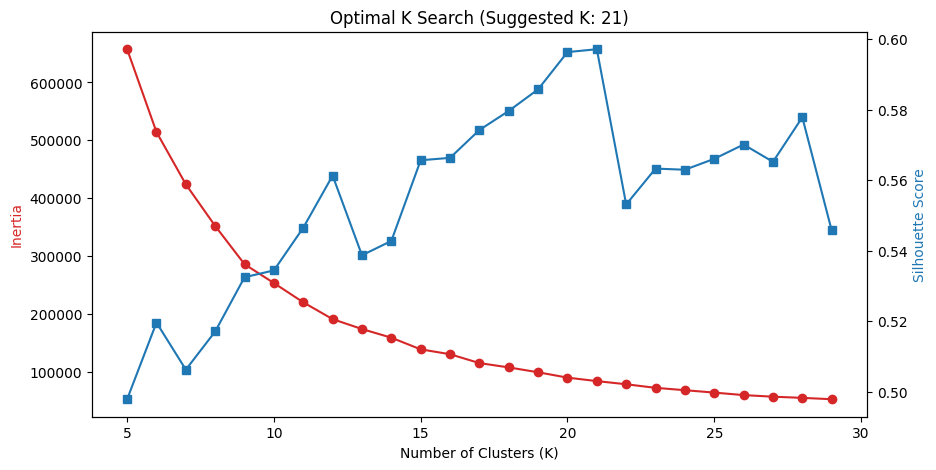

In [7]:
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of K to test
K_range = range(5, 30)
inertias = []
silhouette_scores = []
SAMPLE_SIZE = 5000 # Sampling for faster silhouette calculation

print("Calculating Elbow and Silhouette metrics...")
for k in tqdm(K_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings_2d)
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(embeddings_2d, labels, sample_size=min(SAMPLE_SIZE, len(embeddings_2d)), random_state=42)
    silhouette_scores.append(score)

# Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertias, marker='o', color='tab:red', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color='tab:red')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, marker='s', color='tab:blue', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='tab:blue')

best_k = K_range[np.argmax(silhouette_scores)]
plt.title(f'Optimal K Search (Suggested K: {best_k})')
plt.show()

### **K-MEANS CLUSTERING AND INTERACTIVE VISUALIZATION**
Using the optimal K found, the code below performs the final clustering that is visualized in an interactive scatter plot, where each point represents a single pass, color-coded by its tactical cluster.

In [8]:
import plotly.express as px

N_CLUSTERS = best_k
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_events['Cluster'] = kmeans.fit_predict(embeddings_2d).astype(str)

# Prepare hover information
df_events['info_string'] = (
    "Cluster: " + df_events['Cluster'] + "<br>" +
    "Zone: " + df_events['zone'].astype(str) + "<br>" +
    "Length: " + df_events['length'].round(1).astype(str) + "m<br>" +
    "Pressure: " + (df_events['pressure']*100).round(0).astype(str) + "%<br>" +
    "Duration: " + df_events['duration'].round(1).astype(str) + "s"
)

fig = px.scatter(
    df_events, x='umap_x', y='umap_y', color='Cluster',
    hover_name='info_string',
    title="<b>Tactical Pass clusters</b>",
    template='plotly_dark',
    color_discrete_sequence=px.colors.qualitative.Bold,
    width=900, height=600
)
fig.show()

### **DYNAMIC TACTICAL PROFILING**
To give meaning to these mathematical clusters, the following cell below computes the tactical profile for each cluster by calculating its centroid across key metrics. By identifying which **centroid** exhibits the most extreme values for specific features, tactical labels are assigned to the emerging behaviors.

In [9]:
print("\n--- TACTICAL CLUSTER PROFILING ---")

# Aggregate metrics for each cluster
profile = df_events.groupby('Cluster').agg({
    'length': 'mean',
    'progressive_dist': 'mean',
    'pressure': 'mean',         
    'start_x': 'mean',          
    'start_y': 'mean',
    'duration': 'mean'
}).sort_values('length')

# Dynamic labeling logic
available_clusters = list(profile.index)
CLUSTER_LABELS = {}

c_press = profile.loc[available_clusters]['pressure'].idxmax()
CLUSTER_LABELS[c_press] = "High pressure"
available_clusters.remove(c_press)

c_long = profile.loc[available_clusters]['length'].idxmax()
CLUSTER_LABELS[c_long] = "Deep playmaker"
available_clusters.remove(c_long)

c_recycle = profile.loc[available_clusters]['progressive_dist'].idxmin()
CLUSTER_LABELS[c_recycle] = "Possession recycling"
available_clusters.remove(c_recycle)

c_def = profile.loc[available_clusters]['start_x'].idxmin()
CLUSTER_LABELS[c_def] = "Defensive Build-up"
available_clusters.remove(c_def)

short_clusters = profile.loc[available_clusters].sort_values('length').head(1)
c_comb = short_clusters.index[0]
CLUSTER_LABELS[c_comb] = "Combinations"
available_clusters.remove(c_comb)

if available_clusters:
    c_prog = profile.loc[available_clusters]['progressive_dist'].idxmax()
    CLUSTER_LABELS[c_prog] = "Standard progression"
    available_clusters.remove(c_prog)

profile['Tactical Label'] = profile.index.map(CLUSTER_LABELS).fillna("Not identified")

# Move Tactical Label to the first column for better readability
cols = ['Tactical Label'] + [c for c in profile.columns if c != 'Tactical Label']
profile = profile[cols].sort_values('length', ascending=False)

display(profile)
print("Dynamic labels successfully assigned based on cluster centroids.")


--- TACTICAL CLUSTER PROFILING ---


,Tactical Label,length,progressive_dist,pressure,start_x,start_y,duration
Cluster,,,,,,,
6,Deep playmaker,35.765462,24.060762,0.329557,46.226571,40.408857,4.395469
10,Standard progression,32.735708,21.674227,0.000000,59.542955,40.617869,4.033677
5,Not identified,29.685690,19.574682,0.002648,68.543962,40.888771,3.962924
18,Not identified,29.120967,20.160225,0.000805,52.186795,41.082126,4.273752
9,Possession recycling,24.668087,-18.271146,0.246245,79.656522,39.118577,4.086166
7,Not identified,23.033763,6.344768,0.000000,55.349619,39.765419,3.533264
4,Not identified,22.156684,4.926051,0.000000,50.608990,40.278879,3.521508
19,Not identified,21.631161,5.031048,0.000000,58.778784,40.614489,3.394998
14,Not identified,20.332945,12.266667,1.000000,64.598312,39.443882,3.767089


Dynamic labels successfully assigned based on cluster centroids.


### **PITCH GRID VISUALIZATION**

The final validation of the model is seeing how these clusters map back to the physical pitch. The cell below visualize the density of pass starts and the average directional arrow for each tactical style using `mplsoccer`.

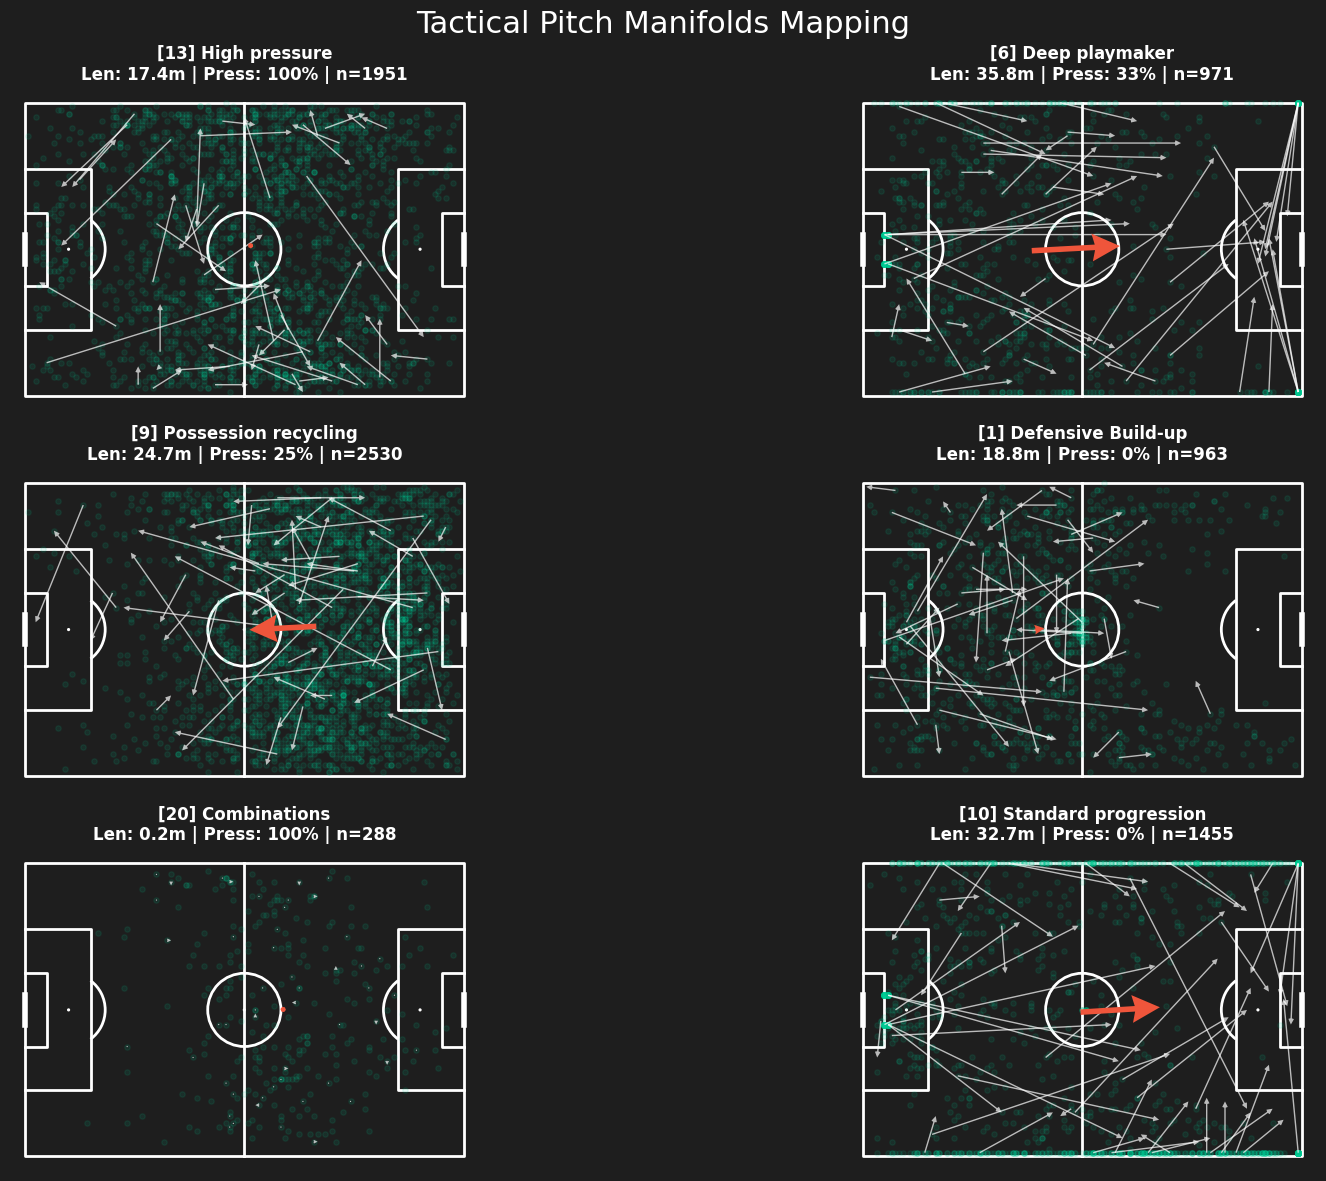

In [10]:
from mplsoccer import Pitch

# Filter clusters for which we have labels
CLUSTERS_TO_VISUALIZE = list(CLUSTER_LABELS.keys())[:6]
nrows, ncols = 3, 2
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12), facecolor='#1e1e1e')
axs = axs.flatten()

pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='white')

for i, ax in enumerate(axs):
    if i >= len(CLUSTERS_TO_VISUALIZE):
        ax.axis('off')
        continue
        
    cluster_id = CLUSTERS_TO_VISUALIZE[i] 
    subset = df_events[df_events['Cluster'] == cluster_id]
    
    pitch.draw(ax=ax)
    
    # Density plot of pass origins
    pitch.scatter(subset.start_x, subset.start_y, ax=ax, color='#00CC96', s=15, alpha=0.1, zorder=1)
    
    # Arrow for a random sample of passes
    sample_size = min(50, len(subset))
    sample = subset.sample(sample_size, random_state=42)
    
    pitch.arrows(sample.start_x, sample.start_y, sample.end_x, sample.end_y,
                 ax=ax, color='white', alpha=0.7, width=1, 
                 headwidth=4, headlength=4, zorder=2)
    
    # Centroid arrow
    mean_start_x, mean_start_y = subset.start_x.mean(), subset.start_y.mean()
    mean_end_x, mean_end_y = subset.end_x.mean(), subset.end_y.mean()
    
    pitch.arrows(mean_start_x, mean_start_y, mean_end_x, mean_end_y, 
                 ax=ax, color='#EF553B', width=4, 
                 headwidth=5, headlength=5, zorder=3, label='Centroid')
    
    # Cluster profiling title
    avg_len = subset['length'].mean()
    avg_press = subset['pressure'].mean() * 100
    label = CLUSTER_LABELS.get(cluster_id, "Unknown Style")
    
    ax.set_title(f"[{cluster_id}] {label}\n"
                 f"Len: {avg_len:.1f}m | Press: {avg_press:.0f}% | n={len(subset)}", 
                 color='white', fontsize=12, fontweight='bold')

plt.suptitle("Tactical Pitch Manifolds Mapping", color='white', fontsize=22, y=0.98)
plt.tight_layout()
plt.show()

- **High Pressure**: captures the chaotic nature of escaping from pressing situations. With 100% pressure, the scattered pass origins and the nearly non-existent directional vector suggest that these are reactionary passes for immediate ball safety.

- **Deep playmaker**: these long-range vectors (35.8m average) originate deep in the defensive zone and point decisively toward the attacking half. The model has isolated the passes that bypass the midfield to find teammates in advanced positions. A sort of 

- **Possession recycling**: is characterized by a strong backward-pointing centroid, these passes occur primarily in the middle and attacking zones. It represents the understanding of tactical resets: choosing to move the ball away from the opponent's goal to maintain possession.

- **Defensive Build-up**: shows structured, unpressed (0%) circulation in the defensive half. The tight density of origins around the center-back positions and the low progression suggests that the model identifies low-risk passing sequences used to prepare the team's shape.

- **Combinations**: with an average length of 0.2m under 100% pressure, this represents extremely congested central play. It captures micro-passes that move the ball very quickly.

- **Standard progression**: is the transition phase. Similar to the playmaker cluster but occurring under zero pressure, these long forward passes represent efficient ball progression. The strong, forward-facing mean vector identifies the standard tactical path for advancing into the final third of the pitch.